In [1]:
import json
import matplotlib.pyplot as plt
import numpy as np

# Load all federated results
base = r"E:\Me\coding\8th Sem\Final Project\Codes\Fe-Learn-Datapoisoing\evaluation"

with open(f'{base}/mnist_mlp_iid_results.json') as f:
    mnist_iid = json.load(f)

with open(f'{base}/mnist_mlp_noniid_results.json') as f:
    mnist_noniid = json.load(f)

with open(f'{base}/emnist_mlp_iid_results.json') as f:
    emnist_iid = json.load(f)

with open(f'{base}/emnist_mlp_noniid_results.json') as f:
    emnist_noniid = json.load(f)

with open(f'{base}/mnist_mlp_centralized_results.json') as f:
    centralized = json.load(f)

# Extract values
rounds = list(range(1, 21))

mnist_iid_acc     = [r[1]*100 for r in mnist_iid['accuracy']]
mnist_noniid_acc  = [r[1]*100 for r in mnist_noniid['accuracy']]
emnist_iid_acc    = [r[1]*100 for r in emnist_iid['accuracy']]
emnist_noniid_acc = [r[1]*100 for r in emnist_noniid['accuracy']]
centralized_acc   = max(centralized['test_accs']) * 100

print(f"MNIST IID final:      {mnist_iid_acc[-1]:.2f}%")
print(f"MNIST Non-IID final:  {mnist_noniid_acc[-1]:.2f}%")
print(f"EMNIST IID final:     {emnist_iid_acc[-1]:.2f}%")
print(f"EMNIST Non-IID final: {emnist_noniid_acc[-1]:.2f}%")
print(f"Centralized final:    {centralized_acc:.2f}%")

MNIST IID final:      97.98%
MNIST Non-IID final:  93.48%
EMNIST IID final:     73.12%
EMNIST Non-IID final: 60.86%
Centralized final:    98.16%


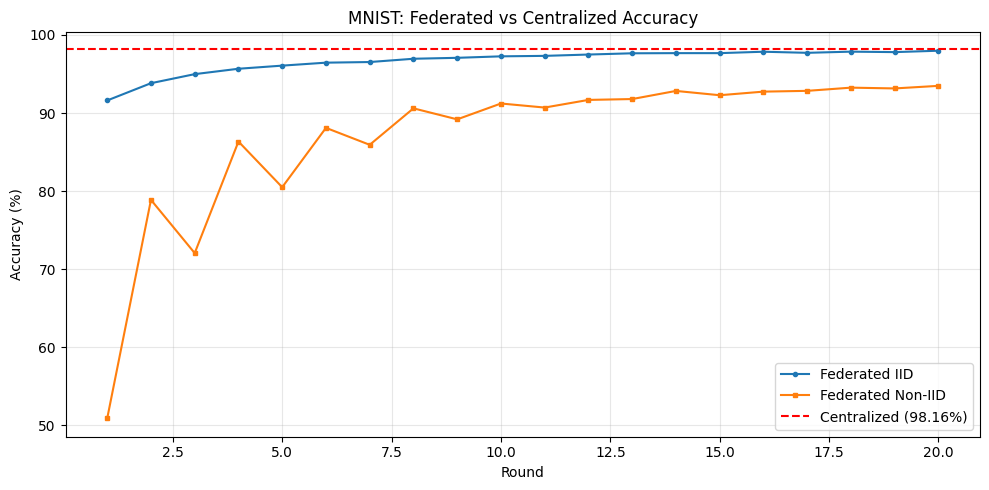

IID gap from centralized:     0.18%
Non-IID gap from centralized: 4.68%


In [2]:
plt.figure(figsize=(10, 5))
plt.plot(rounds, mnist_iid_acc, marker='o', markersize=3, label='Federated IID')
plt.plot(rounds, mnist_noniid_acc, marker='s', markersize=3, label='Federated Non-IID')
plt.axhline(y=centralized_acc, color='r', linestyle='--', label=f'Centralized ({centralized_acc:.2f}%)')
plt.xlabel('Round')
plt.ylabel('Accuracy (%)')
plt.title('MNIST: Federated vs Centralized Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{base}/mnist_federated_vs_centralized.png', dpi=150)
plt.show()
print(f"IID gap from centralized:     {centralized_acc - mnist_iid_acc[-1]:.2f}%")
print(f"Non-IID gap from centralized: {centralized_acc - mnist_noniid_acc[-1]:.2f}%")

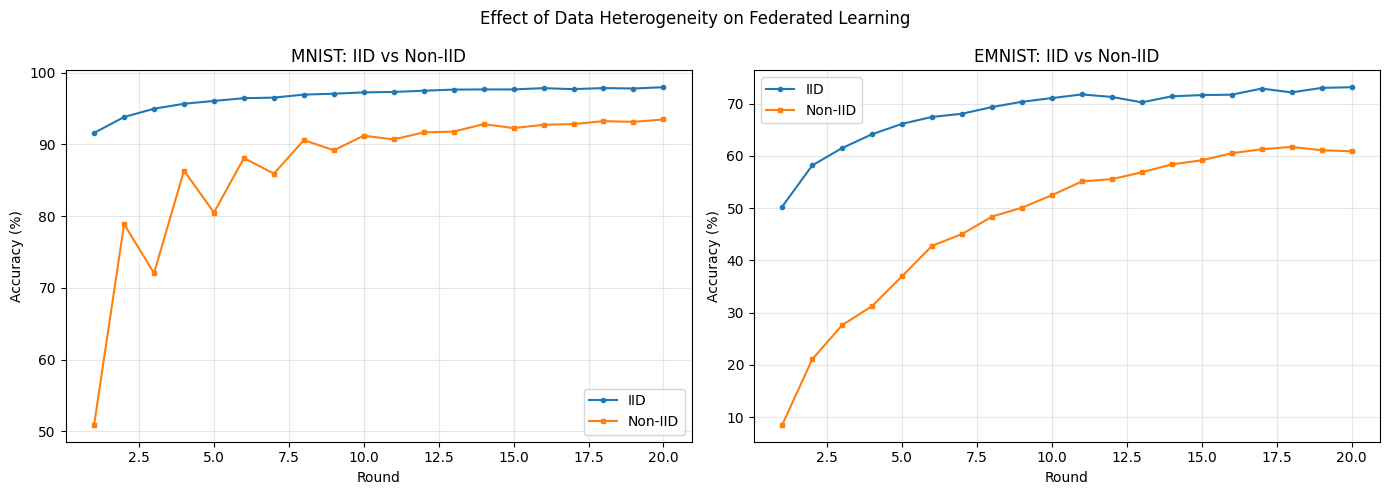

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# MNIST
axes[0].plot(rounds, mnist_iid_acc, marker='o', markersize=3, label='IID')
axes[0].plot(rounds, mnist_noniid_acc, marker='s', markersize=3, label='Non-IID')
axes[0].set_title('MNIST: IID vs Non-IID')
axes[0].set_xlabel('Round')
axes[0].set_ylabel('Accuracy (%)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# EMNIST
axes[1].plot(rounds, emnist_iid_acc, marker='o', markersize=3, label='IID')
axes[1].plot(rounds, emnist_noniid_acc, marker='s', markersize=3, label='Non-IID')
axes[1].set_title('EMNIST: IID vs Non-IID')
axes[1].set_xlabel('Round')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Effect of Data Heterogeneity on Federated Learning')
plt.tight_layout()
plt.savefig(f'{base}/iid_vs_noniid_comparison.png', dpi=150)
plt.show()

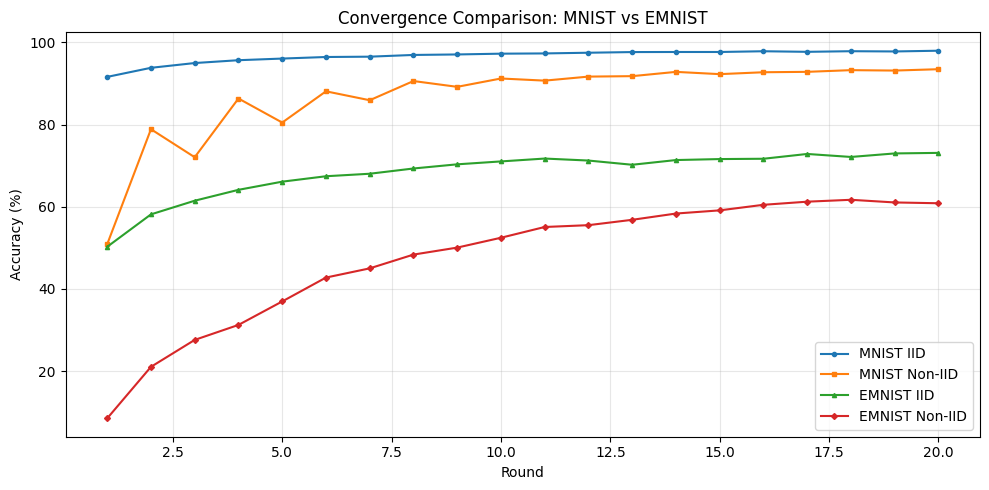

In [4]:
plt.figure(figsize=(10, 5))
plt.plot(rounds, mnist_iid_acc, marker='o', markersize=3, label='MNIST IID')
plt.plot(rounds, mnist_noniid_acc, marker='s', markersize=3, label='MNIST Non-IID')
plt.plot(rounds, emnist_iid_acc, marker='^', markersize=3, label='EMNIST IID')
plt.plot(rounds, emnist_noniid_acc, marker='D', markersize=3, label='EMNIST Non-IID')
plt.xlabel('Round')
plt.ylabel('Accuracy (%)')
plt.title('Convergence Comparison: MNIST vs EMNIST')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{base}/mnist_vs_emnist_convergence.png', dpi=150)
plt.show()

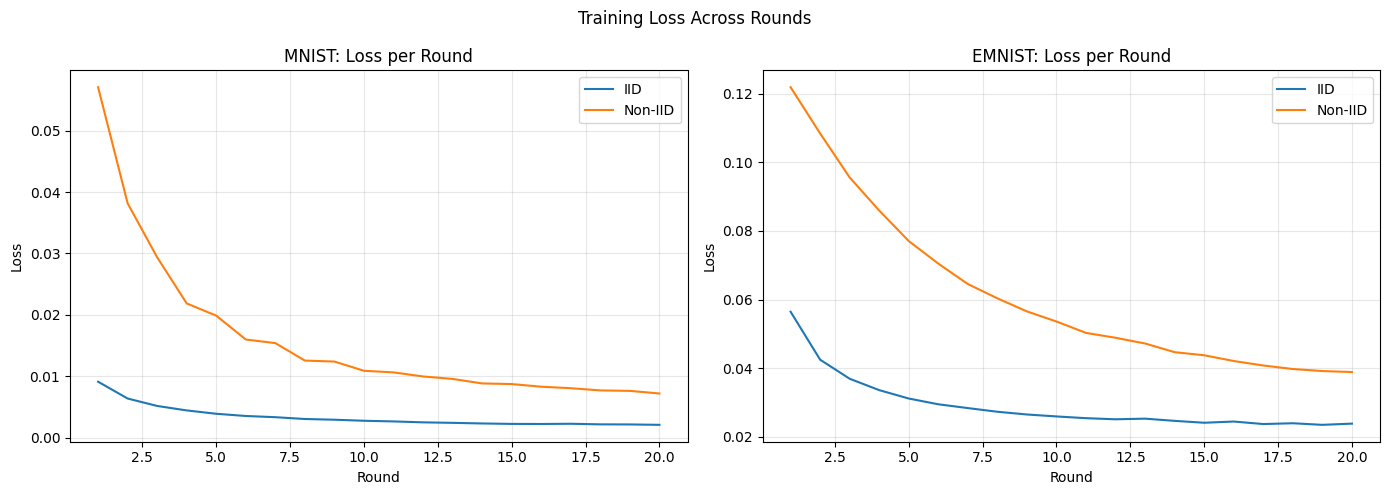

In [5]:
mnist_iid_loss     = [r[1] for r in mnist_iid['loss']]
mnist_noniid_loss  = [r[1] for r in mnist_noniid['loss']]
emnist_iid_loss    = [r[1] for r in emnist_iid['loss']]
emnist_noniid_loss = [r[1] for r in emnist_noniid['loss']]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(rounds, mnist_iid_loss, label='IID')
axes[0].plot(rounds, mnist_noniid_loss, label='Non-IID')
axes[0].set_title('MNIST: Loss per Round')
axes[0].set_xlabel('Round')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(rounds, emnist_iid_loss, label='IID')
axes[1].plot(rounds, emnist_noniid_loss, label='Non-IID')
axes[1].set_title('EMNIST: Loss per Round')
axes[1].set_xlabel('Round')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Training Loss Across Rounds')
plt.tight_layout()
plt.savefig(f'{base}/loss_curves.png', dpi=150)
plt.show()

In [6]:
print("=" * 60)
print(f"{'Setup':<25} {'Round 1':>10} {'Round 20':>10} {'Gap':>10}")
print("=" * 60)
print(f"{'MNIST IID':<25} {mnist_iid_acc[0]:>9.2f}% {mnist_iid_acc[-1]:>9.2f}% {centralized_acc - mnist_iid_acc[-1]:>9.2f}%")
print(f"{'MNIST Non-IID':<25} {mnist_noniid_acc[0]:>9.2f}% {mnist_noniid_acc[-1]:>9.2f}% {centralized_acc - mnist_noniid_acc[-1]:>9.2f}%")
print(f"{'EMNIST IID':<25} {emnist_iid_acc[0]:>9.2f}% {emnist_iid_acc[-1]:>9.2f}% {'N/A':>10}")
print(f"{'EMNIST Non-IID':<25} {emnist_noniid_acc[0]:>9.2f}% {emnist_noniid_acc[-1]:>9.2f}% {'N/A':>10}")
print(f"{'Centralized (MNIST)':<25} {'—':>10} {centralized_acc:>9.2f}% {'0.00%':>10}")
print("=" * 60)

Setup                        Round 1   Round 20        Gap
MNIST IID                     91.61%     97.98%      0.18%
MNIST Non-IID                 50.90%     93.48%      4.68%
EMNIST IID                    50.27%     73.12%        N/A
EMNIST Non-IID                 8.52%     60.86%        N/A
Centralized (MNIST)                —     98.16%      0.00%


In [7]:
with open(f'{base}/mnist_cnn_iid_results.json') as f:
    mnist_cnn_iid = json.load(f)

with open(f'{base}/mnist_cnn_noniid_results.json') as f:
    mnist_cnn_noniid = json.load(f)

with open(f'{base}/emnist_cnn_iid_results.json') as f:
    emnist_cnn_iid = json.load(f)

with open(f'{base}/emnist_cnn_noniid_results.json') as f:
    emnist_cnn_noniid = json.load(f)

mnist_cnn_iid_acc     = [r[1]*100 for r in mnist_cnn_iid['accuracy']]
mnist_cnn_noniid_acc  = [r[1]*100 for r in mnist_cnn_noniid['accuracy']]
emnist_cnn_iid_acc    = [r[1]*100 for r in emnist_cnn_iid['accuracy']]
emnist_cnn_noniid_acc = [r[1]*100 for r in emnist_cnn_noniid['accuracy']]

print(f"MNIST CNN IID final:      {mnist_cnn_iid_acc[-1]:.2f}%")
print(f"MNIST CNN Non-IID final:  {mnist_cnn_noniid_acc[-1]:.2f}%")
print(f"EMNIST CNN IID final:     {emnist_cnn_iid_acc[-1]:.2f}%")
print(f"EMNIST CNN Non-IID final: {emnist_cnn_noniid_acc[-1]:.2f}%")

MNIST CNN IID final:      99.16%
MNIST CNN Non-IID final:  97.89%
EMNIST CNN IID final:     78.68%
EMNIST CNN Non-IID final: 71.90%


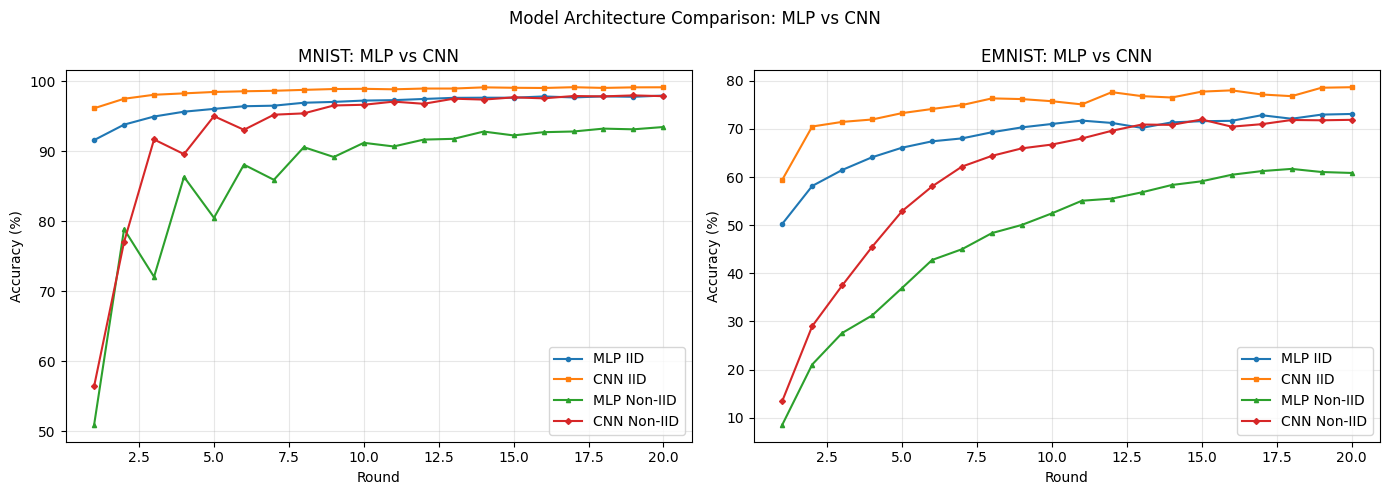

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(rounds, mnist_iid_acc, marker='o', markersize=3, label='MLP IID')
axes[0].plot(rounds, mnist_cnn_iid_acc, marker='s', markersize=3, label='CNN IID')
axes[0].plot(rounds, mnist_noniid_acc, marker='^', markersize=3, label='MLP Non-IID')
axes[0].plot(rounds, mnist_cnn_noniid_acc, marker='D', markersize=3, label='CNN Non-IID')
axes[0].set_title('MNIST: MLP vs CNN')
axes[0].set_xlabel('Round')
axes[0].set_ylabel('Accuracy (%)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(rounds, emnist_iid_acc, marker='o', markersize=3, label='MLP IID')
axes[1].plot(rounds, emnist_cnn_iid_acc, marker='s', markersize=3, label='CNN IID')
axes[1].plot(rounds, emnist_noniid_acc, marker='^', markersize=3, label='MLP Non-IID')
axes[1].plot(rounds, emnist_cnn_noniid_acc, marker='D', markersize=3, label='CNN Non-IID')
axes[1].set_title('EMNIST: MLP vs CNN')
axes[1].set_xlabel('Round')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Model Architecture Comparison: MLP vs CNN')
plt.tight_layout()
plt.savefig(f'{base}/mlp_vs_cnn_comparison.png', dpi=150)
plt.show()

In [9]:
print("=" * 70)
print(f"{'Setup':<30} {'Round 1':>10} {'Round 20':>10}")
print("=" * 70)
print(f"{'MNIST MLP IID':<30} {mnist_iid_acc[0]:>9.2f}% {mnist_iid_acc[-1]:>9.2f}%")
print(f"{'MNIST CNN IID':<30} {mnist_cnn_iid_acc[0]:>9.2f}% {mnist_cnn_iid_acc[-1]:>9.2f}%")
print(f"{'MNIST MLP Non-IID':<30} {mnist_noniid_acc[0]:>9.2f}% {mnist_noniid_acc[-1]:>9.2f}%")
print(f"{'MNIST CNN Non-IID':<30} {mnist_cnn_noniid_acc[0]:>9.2f}% {mnist_cnn_noniid_acc[-1]:>9.2f}%")
print("-" * 70)
print(f"{'EMNIST MLP IID':<30} {emnist_iid_acc[0]:>9.2f}% {emnist_iid_acc[-1]:>9.2f}%")
print(f"{'EMNIST CNN IID':<30} {emnist_cnn_iid_acc[0]:>9.2f}% {emnist_cnn_iid_acc[-1]:>9.2f}%")
print(f"{'EMNIST MLP Non-IID':<30} {emnist_noniid_acc[0]:>9.2f}% {emnist_noniid_acc[-1]:>9.2f}%")
print(f"{'EMNIST CNN Non-IID':<30} {emnist_cnn_noniid_acc[0]:>9.2f}% {emnist_cnn_noniid_acc[-1]:>9.2f}%")
print("-" * 70)
print(f"{'Centralized MNIST MLP':<30} {'—':>10} {centralized_acc:>9.2f}%")
print("=" * 70)

Setup                             Round 1   Round 20
MNIST MLP IID                      91.61%     97.98%
MNIST CNN IID                      96.16%     99.16%
MNIST MLP Non-IID                  50.90%     93.48%
MNIST CNN Non-IID                  56.42%     97.89%
----------------------------------------------------------------------
EMNIST MLP IID                     50.27%     73.12%
EMNIST CNN IID                     59.43%     78.68%
EMNIST MLP Non-IID                  8.52%     60.86%
EMNIST CNN Non-IID                 13.45%     71.90%
----------------------------------------------------------------------
Centralized MNIST MLP                   —     98.16%
